In [ ]:
import os
import shutil
from google.colab import drive

# 1. Unmount just in case it's in a weird half-mounted state
try:
    drive.flush_and_unmount()
    print("Unmounted existing drive state.")
except:
    pass

# 2. Delete the fake local directory that is blocking the mount
if os.path.exists('/content/drive'):
    print("Removing the fake/conflicting '/content/drive' folder...")
    shutil.rmtree('/content/drive')

# 3. Mount properly and cleanly
print("Mounting real Google Drive...")
drive.mount('/content/drive')
print(" Mount completely successful!")

Drive not mounted, so nothing to flush and unmount.
Unmounted existing drive state.
Mounting real Google Drive...
Mounted at /content/drive
✅ Mount completely successful!


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

BASE_DIR = '/content/drive/MyDrive/extracted_frames'
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
FRAMES_DIR = os.path.join(BASE_DIR, 'frames')

def extract_frames(video_path, output_folder, num_frames=25):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < num_frames:
        frame_indices = np.arange(total_frames)
    else:
        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    count = 0
    current_frame = 0

    while cap.isOpened() and count < len(frame_indices):
        ret, frame = cap.read()
        if not ret:
            break
        if current_frame == frame_indices[count]:
            frame_name = f"frame_{count:03d}.jpg"
            #saving frame
            cv2.imwrite(os.path.join(output_folder, frame_name), frame)
            count += 1
        current_frame += 1

    cap.release()

splits = ['train', 'val', 'test']
classes = ['ai_videos', 'real_videos']

for split in splits:
    for cls in classes:
        vid_dir = os.path.join(DATASET_DIR, split, cls)
        out_cls = 'ai' if 'ai' in cls else 'real'

        if not os.path.exists(vid_dir):
            print(f" Skipping {split}/{cls} - Folder not found")
            continue

        videos = [v for v in os.listdir(vid_dir) if v.endswith('.mp4')]
        if not videos:
            print(f" Skipping {split}/{cls} - No .mp4 files inside")
            continue

        print(f"▶️ Extracting {split}/{cls} - {len(videos)} videos")

        for vid in tqdm(videos):
            vid_path = os.path.join(vid_dir, vid)
            vid_name = os.path.splitext(vid)[0]
            out_folder = os.path.join(FRAMES_DIR, split, out_cls, vid_name)
            extract_frames(vid_path, out_folder, num_frames=25)

print("\n All RGB frames extracted successfully!")

▶️ Extracting train/ai_videos - 92 videos


100%|██████████| 92/92 [04:24<00:00,  2.87s/it]


▶️ Extracting train/real_videos - 91 videos


100%|██████████| 91/91 [05:01<00:00,  3.31s/it]


▶️ Extracting val/ai_videos - 28 videos


...

▶️ Extracting test/ai_videos - 28 videos


100%|██████████| 28/28 [01:20<00:00,  2.87s/it]


▶️ Extracting test/real_videos - 26 videos


100%|██████████| 26/26 [01:20<00:00,  3.10s/it]


✅ All RGB frames extracted successfully!


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
from google.colab import drive

print("1. Connecting to Drive & Setting up...")
drive.mount('/content/drive', force_remount=True)

BASE_DIR = '/content/drive/MyDrive/extracted_frames'
FRAMES_DIR = os.path.join(BASE_DIR, 'frames')
FFT_DIR = os.path.join(BASE_DIR, 'fft_frames')
model_save_path = os.path.join(BASE_DIR, 'best_hybrid_model_v2.pth')
old_model_path = os.path.join(BASE_DIR, 'best_hybrid_model.pth')

# ==========================================
# 2. DATALOADERS
# ==========================================
class HybridVideoDataset(Dataset):
    def __init__(self, rgb_dir, fft_dir, transform=None):
        self.rgb_dir = rgb_dir
        self.fft_dir = fft_dir
        self.transform = transform
        self.samples = []

        class_to_idx = {'real': 0, 'ai': 1}
        for cls in class_to_idx.keys():
            #rgb folder
            cls_rgb_dir = os.path.join(rgb_dir, cls)
            if not os.path.exists(cls_rgb_dir): continue
            #loop through videos
            for vid_folder in os.listdir(cls_rgb_dir):
                vid_rgb_dir = os.path.join(cls_rgb_dir, vid_folder)
                vid_fft_dir = os.path.join(fft_dir, cls, vid_folder)
                if not os.path.exists(vid_fft_dir): continue

                for frame_file in os.listdir(vid_rgb_dir):
                    rgb_path = os.path.join(vid_rgb_dir, frame_file)
                    fft_path = os.path.join(vid_fft_dir, frame_file)
                    if os.path.exists(fft_path):
                        self.samples.append((rgb_path, fft_path, class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, fft_path, label = self.samples[idx]
        rgb_img = Image.open(rgb_path).convert('RGB')
        fft_img = Image.open(fft_path).convert('RGB')

        if self.transform:
            #preprocessing
            rgb_img = self.transform(rgb_img)
            fft_img = self.transform(fft_img)
        return rgb_img, fft_img, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("\n2. Building DataLoaders...")
train_dataset = HybridVideoDataset(os.path.join(FRAMES_DIR, 'train'), os.path.join(FFT_DIR, 'train'), transform)
val_dataset = HybridVideoDataset(os.path.join(FRAMES_DIR, 'val'), os.path.join(FFT_DIR, 'val'), transform)
test_dataset = HybridVideoDataset(os.path.join(FRAMES_DIR, 'test'), os.path.join(FFT_DIR, 'test'), transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f" Loaders ready! Train frames: {len(train_dataset)}")

# ==========================================
# 3. MODEL ARCHITECTURE & WEIGHT LOADING
# ==========================================
class HybridResNet(nn.Module):
    def __init__(self, num_classes=2):
        super(HybridResNet, self).__init__()
        self.rgb_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs_rgb = self.rgb_branch.fc.in_features #512
        self.rgb_branch.fc = nn.Identity()

        self.fft_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs_fft = self.fft_branch.fc.in_features
        self.fft_branch.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs_rgb + num_ftrs_fft, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, rgb, fft):
        feat_rgb = self.rgb_branch(rgb)
        feat_fft = self.fft_branch(fft)
        return self.classifier(torch.cat((feat_rgb, feat_fft), dim=1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridResNet(num_classes=2).to(device)

# Automatically load the best available weights
if os.path.exists(model_save_path):
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    print(f" Successfully loaded newer V2 weights from: {model_save_path}")
elif os.path.exists(old_model_path):
    model.load_state_dict(torch.load(old_model_path, map_location=device))
    print(f" Successfully loaded original base weights from: {old_model_path}")
else:
    print(" No previous weights found in Drive. Starting training from scratch.")

# ==========================================
# 4. TRAINING LOOP (With Class Weights & Early Stopping)
# ==========================================
print("\n4. Starting Training Phase...")
weights = torch.tensor([1.0, 1.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
patience = 3
epochs_no_improve = 0
best_val_acc = 0.0

print(f"Launching {epochs}-Epoch Loop (Patience={patience})...\n")

for epoch in range(epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for rgb, fft, labels in loop:
        rgb, fft, labels = rgb.to(device), fft.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(rgb, fft)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data)
        total_train += labels.size(0)
        loop.set_postfix(loss=loss.item())

    train_acc = correct_train.double() / total_train

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for rgb, fft, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            rgb, fft, labels = rgb.to(device), fft.to(device), labels.to(device)
            outputs = model(rgb, fft)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data)
            total_val += labels.size(0)

    val_acc = correct_val.double() / total_val
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"\n📈 Epoch {epoch+1} Results: Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f" New Best Model Saved to V2! (Val Acc: {val_acc:.4f})\n")
    else:
        epochs_no_improve += 1
        print(f" No improvement. Patience: {epochs_no_improve}/{patience}\n")

        if epochs_no_improve >= patience:
            print("Early Stopping triggered! The model has stopped improving.")
            break

print(" Training Complete!")

1. Connecting to Drive & Setting up...
Mounted at /content/drive

2. Building DataLoaders...
✅ Loaders ready! Train frames: 3498

3. Rebuilding AI Brain & Loading Memories...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


🌟 Successfully loaded original base weights from: /content/drive/MyDrive/extracted_frames/best_hybrid_model.pth

4. Starting Training Phase...
🚀 Launching 10-Epoch Loop (Patience=3)...



Epoch 1/10 [Val]: 100%|██████████| 24/24 [09:14<00:00, 23.12s/it]



📈 Epoch 1 Results: Train Acc: 0.9937 | Val Acc: 0.7413
⭐ New Best Model Saved to V2! (Val Acc: 0.7413)



...


📈 Epoch 5 Results: Train Acc: 0.9969 | Val Acc: 0.7733
⚠️ No improvement. Patience: 1/3



Epoch 6/10 [Val]: 100%|██████████| 24/24 [00:30<00:00,  1.26s/it]



📈 Epoch 6 Results: Train Acc: 0.9994 | Val Acc: 0.7933
⚠️ No improvement. Patience: 2/3



Epoch 7/10 [Val]: 100%|██████████| 24/24 [00:30<00:00,  1.29s/it]


📈 Epoch 7 Results: Train Acc: 0.9991 | Val Acc: 0.7800
⚠️ No improvement. Patience: 3/3

🛑 Early Stopping triggered! The model has stopped improving.
🏁 Training Complete!


🔍 Loading the Peak V2 Model for Final Evaluation...


Testing Unseen Data: 100%|██████████| 24/24 [09:20<00:00, 23.35s/it]



🏆 FINAL V2 TEST RESULTS 🏆
Final Test Accuracy : 0.8879 (88.79%)

📊 Detailed Classification Report:
              precision    recall  f1-score   support

    Real (0)     0.8489    0.9440    0.8939       375
      AI (1)     0.9367    0.8316    0.8810       374

    accuracy                         0.8879       749
   macro avg     0.8928    0.8878    0.8875       749
weighted avg     0.8928    0.8879    0.8875       749



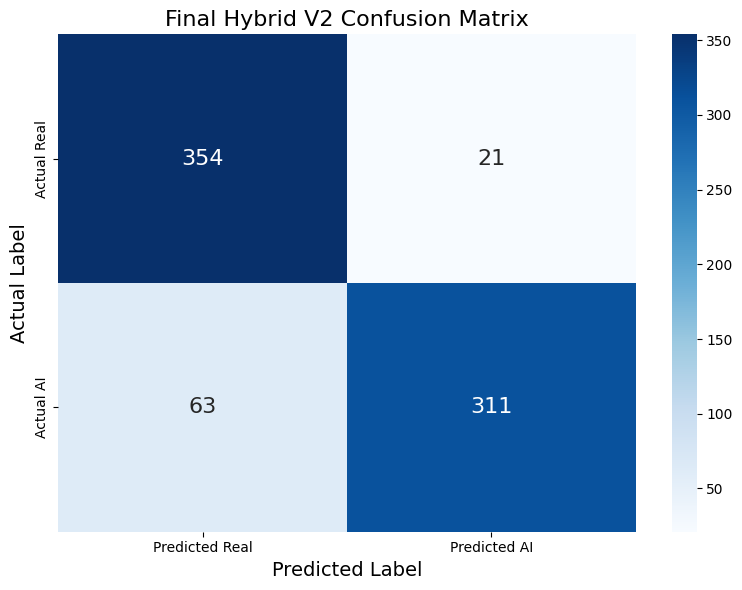

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm import tqdm

print(" Loading the Peak V2 Model for Final Evaluation...")
# Load the best weights we just saved at Epoch 4
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for rgb, fft, labels in tqdm(test_loader, desc="Testing Unseen Data"):
        rgb, fft, labels = rgb.to(device), fft.to(device), labels.to(device)
        outputs = model(rgb, fft)

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Final Metrics
final_acc = accuracy_score(all_labels, all_preds)

print("\n" + "="*50)
print(" FINAL V2 TEST RESULTS ")
print("="*50)
print(f"Final Test Accuracy : {final_acc:.4f} ({final_acc*100:.2f}%)")
print("="*50)

print("\nDetailed Classification Report:")
# target_names: 0 is Real, 1 is AI
print(classification_report(all_labels, all_preds, target_names=['Real (0)', 'AI (1)'], digits=4))

# Generate the beautiful Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Real', 'Predicted AI'],
            yticklabels=['Actual Real', 'Actual AI'],
            annot_kws={"size": 16})
plt.title('Final Hybrid V2 Confusion Matrix', fontsize=16)
plt.ylabel('Actual Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# 1. SETUP & DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. BUILD THE HYBRID ARCHITECTURE
# ==========================================
class HybridResNet(nn.Module):
    def __init__(self, num_classes=2):
        super(HybridResNet, self).__init__()

        self.rgb_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs_rgb = self.rgb_branch.fc.in_features
        self.rgb_branch.fc = nn.Identity()

        self.fft_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs_fft = self.fft_branch.fc.in_features
        self.fft_branch.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs_rgb + num_ftrs_fft, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, rgb, fft):
        feat_rgb = self.rgb_branch(rgb)
        feat_fft = self.fft_branch(fft)
        return self.classifier(torch.cat((feat_rgb, feat_fft), dim=1))

# Initialize model and load your saved weights
model = HybridResNet(num_classes=2).to(device)
MODEL_SAVE_PATH = '/content/drive/MyDrive/extracted_frames/best_hybrid_model_v2.pth'

if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print(f" AI Brain loaded successfully from: {MODEL_SAVE_PATH}")
else:
    print(f"ERROR: Could not find your saved weights at {MODEL_SAVE_PATH}!")

# ==========================================
# 3. VIDEO PREDICTION FUNCTION (25 Frames)
# ==========================================
def predict_video(video_path, model, transform, device, num_frames=25):
    model.eval()
    cap     = cv2.VideoCapture(video_path)
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        return None

    indices = np.linspace(0, total - 1, min(num_frames, total), dtype=int)

    frames_rgb, frames_fft = [], []
    count = cur = 0
    while cap.isOpened() and count < len(indices):
        ret, frame = cap.read()
        if not ret: break
        if cur == indices[count]:
            # RGB
            rgb_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            frames_rgb.append(transform(rgb_img))

            # FFT
            gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            f_shift = np.fft.fftshift(np.fft.fft2(gray))
            mag     = 20 * np.log(np.abs(f_shift) + 1e-8)
            mag     = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
            fft_img = Image.fromarray(np.uint8(mag)).convert('RGB')
            frames_fft.append(transform(fft_img))

            count += 1
        cur += 1
    cap.release()

    if not frames_rgb:
        return None

    rgb_t = torch.stack(frames_rgb).to(device)
    fft_t = torch.stack(frames_fft).to(device)

    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            outputs = model(rgb_t, fft_t)

    frame_preds = outputs.argmax(dim=1)
    label = torch.mode(frame_preds).values.item()

    real_votes = (frame_preds == 0).sum().item()
    ai_votes   = (frame_preds == 1).sum().item()

    return {
        "prediction": label,
        "real_votes": real_votes,
        "ai_votes": ai_votes
    }


# ==========================================
# 4. EVALUATION LOOP (Final Verified Paths)
# ==========================================
TEST_DIR = "/content/drive/MyDrive/extracted_frames/dataset/test"

all_preds = []
all_labels = []

print("\n Starting Video-Level Evaluation...\n")

# Using the EXACT folder names your diagnostic script just found!
for folder, label in [("real_videos", 0), ("ai_videos", 1)]:
    path = os.path.join(TEST_DIR, folder)

    if not os.path.exists(path):
        print(f"Folder not found: {path}")
        continue

    for video in os.listdir(path):
        if not video.endswith((".mp4", ".avi", ".mov")):
            continue

        video_path = os.path.join(path, video)

        result = predict_video(
            video_path,
            model,
            transform,
            device
        )

        if result is None:
            continue

        all_preds.append(result["prediction"])
        all_labels.append(label)

        print(
            f"{video:<25} "
            f"True={label} | "
            f"Pred={result['prediction']} | "
            f"Real_Votes={result['real_votes']:<2} | "
            f"AI_Votes={result['ai_votes']:<2}"
        )

# ==========================================
# 5. FINAL METRICS
# ==========================================
if all_labels and all_preds:
    print("\n" + "="*50)
    print(" FINAL VIDEO-LEVEL RESULTS")
    print("="*50)

    video_acc = accuracy_score(all_labels, all_preds)
    print(f"Accuracy: {video_acc:.4f} ({video_acc*100:.2f}%)\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=["Real", "AI"],
            digits=4
        )
    )
else:
    print("❌ No videos were successfully processed.")

✅ AI Brain loaded successfully from: /content/drive/MyDrive/extracted_frames/best_hybrid_model_v2.pth

🎬 Starting Video-Level Evaluation...

v03_1.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v14_1.mp4                 True=0 | Pred=0 | Real_Votes=21 | AI_Votes=4 
v25_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v29_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v42_2.mp4                 True=0 | Pred=0 | Real_Votes=20 | AI_Votes=5 
v69_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v51_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v67_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v79_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v47_2.mp4                 True=0 | Pred=1 | Real_Votes=12 | AI_Votes=13
v50_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Votes=0 
v74_2.mp4                 True=0 | Pred=0 | Real_Votes=25 | AI_Vote